In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

In [2]:
print("Загрузка файла results.csv")
uploaded = files.upload()

df = pd.read_csv('results.csv')
print("\nПервые строки данных:")
print(df.head())

Загрузка файла results.csv


Saving results.csv to results (2).csv

Первые строки данных:
  type  size  cpu_time_ms  gpu_time_ms   speedup
0  int   100     0.963367     0.451467   2.13386
1  int   200     8.044630     0.475061  16.93390
2  int   400    82.706600     2.720340  30.40300
3  int   800  1178.670000    24.012900  49.08510
4  int  1000  2225.060000    98.505000  22.58830


График времени выполнения


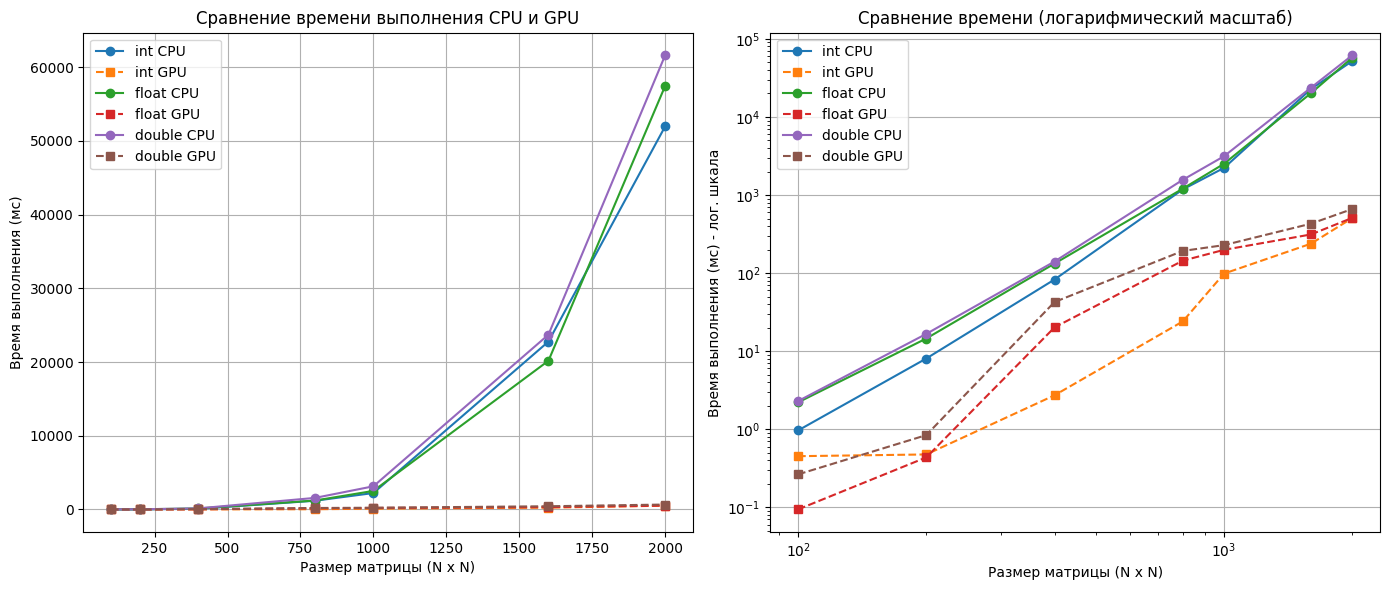

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for dtype in df['type'].unique():
    subset = df[df['type'] == dtype]
    axes[0].plot(subset['size'], subset['cpu_time_ms'], 'o-', label=f'{dtype} CPU')
    axes[0].plot(subset['size'], subset['gpu_time_ms'], 's--', label=f'{dtype} GPU')

axes[0].set_xlabel('Размер матрицы (N x N)')
axes[0].set_ylabel('Время выполнения (мс)')
axes[0].set_title('Сравнение времени выполнения CPU и GPU')
axes[0].legend()
axes[0].grid(True)

for dtype in df['type'].unique():
    subset = df[df['type'] == dtype]
    axes[1].plot(subset['size'], subset['cpu_time_ms'], 'o-', label=f'{dtype} CPU')
    axes[1].plot(subset['size'], subset['gpu_time_ms'], 's--', label=f'{dtype} GPU')

axes[1].set_xlabel('Размер матрицы (N x N)')
axes[1].set_ylabel('Время выполнения (мс) - лог. шкала')
axes[1].set_title('Сравнение времени (логарифмический масштаб)')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('execution_time.png', dpi=150, bbox_inches='tight')
plt.show()

График ускорения

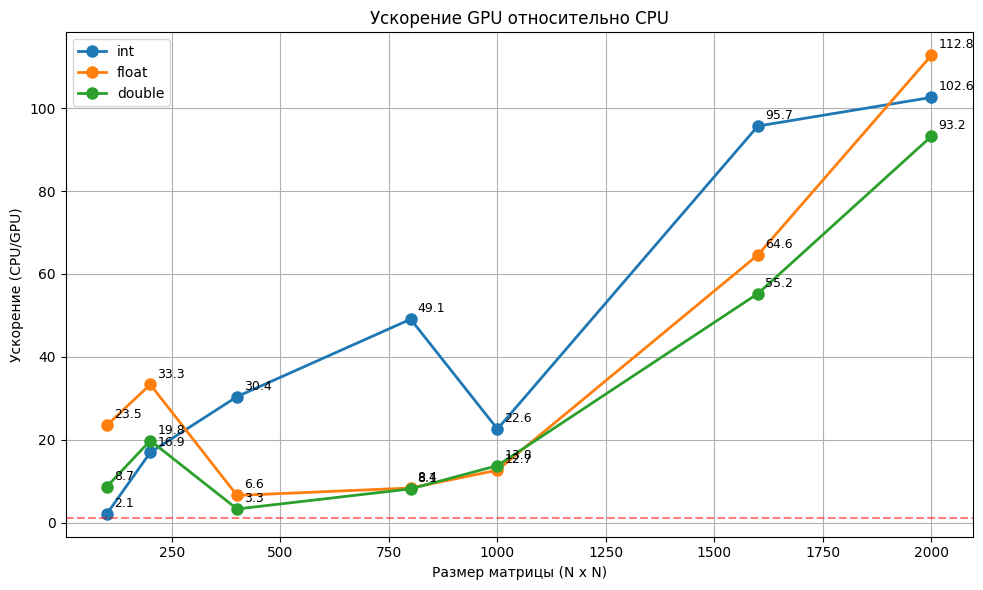

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for dtype in df['type'].unique():
    subset = df[df['type'] == dtype]
    ax.plot(subset['size'], subset['speedup'], 'o-', linewidth=2, markersize=8, label=f'{dtype}')

ax.set_xlabel('Размер матрицы (N x N)')
ax.set_ylabel('Ускорение (CPU/GPU)')
ax.set_title('Ускорение GPU относительно CPU')
ax.legend()
ax.grid(True)
ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)

for dtype in df['type'].unique():
    subset = df[df['type'] == dtype]
    for _, row in subset.iterrows():
        ax.annotate(f'{row["speedup"]:.1f}',
                   xy=(row['size'], row['speedup']),
                   xytext=(5, 5),
                   textcoords='offset points',
                   fontsize=9)

plt.tight_layout()
plt.savefig('speedup.png', dpi=150, bbox_inches='tight')
plt.show()

Таблица результатов

In [5]:
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)

for dtype in df['type'].unique():
    print(f"\n--- {dtype.upper()} ---")
    subset = df[df['type'] == dtype]

    display_df = subset[['size', 'cpu_time_ms', 'gpu_time_ms', 'speedup']].copy()
    display_df.columns = ['Размер', 'CPU (мс)', 'GPU (мс)', 'Ускорение']
    display_df = display_df.round(2)

    print(display_df.to_string(index=False))
    print(f"\nСреднее ускорение: {subset['speedup'].mean():.2f}x")
    print(f"Максимальное ускорение: {subset['speedup'].max():.2f}x")


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

--- INT ---
 Размер  CPU (мс)  GPU (мс)  Ускорение
    100      0.96      0.45       2.13
    200      8.04      0.48      16.93
    400     82.71      2.72      30.40
    800   1178.67     24.01      49.09
   1000   2225.06     98.50      22.59
   1600  22776.30    238.05      95.68
   2000  51976.50    506.60     102.60

Среднее ускорение: 45.63x
Максимальное ускорение: 102.60x

--- FLOAT ---
 Размер  CPU (мс)  GPU (мс)  Ускорение
    100      2.21      0.09      23.49
    200     14.52      0.44      33.33
    400    132.29     20.15       6.56
    800   1205.12    144.16       8.36
   1000   2512.25    198.44      12.66
   1600  20176.50    312.46      64.57
   2000  57464.10    509.62     112.76

Среднее ускорение: 37.39x
Максимальное ускорение: 112.76x

--- DOUBLE ---
 Размер  CPU (мс)  GPU (мс)  Ускорение
    100      2.29      0.26       8.69
    200     16.63      0.84      19.80
    400    140.55     42.57       3.30
    800   1564.56    192.10  

Графики эффективности

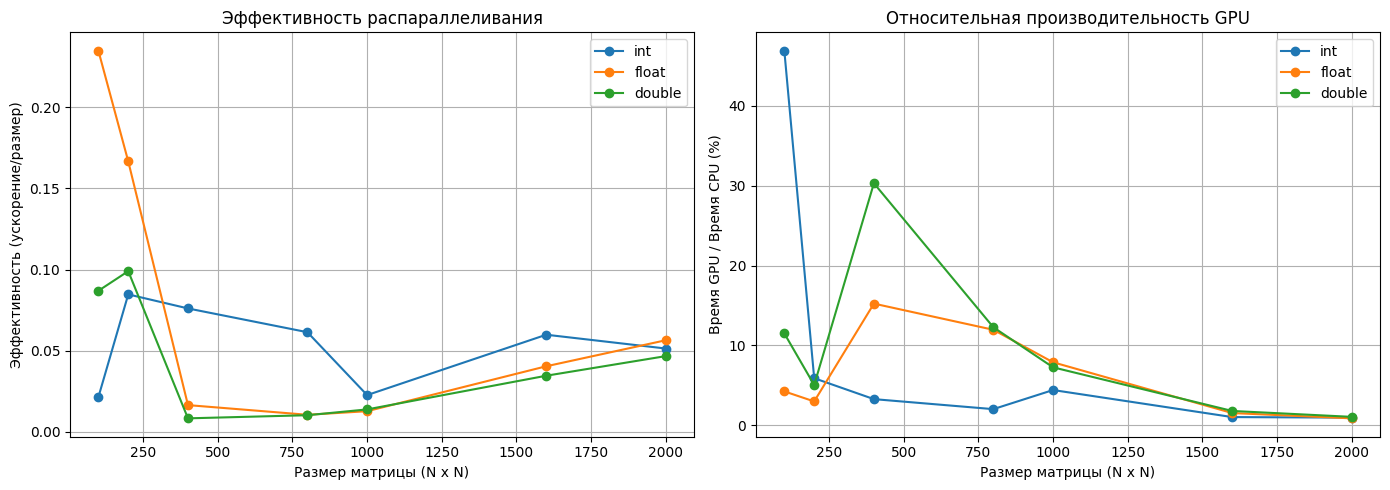

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for dtype in df['type'].unique():
    subset = df[df['type'] == dtype]
    efficiency = subset['speedup'] / subset['size']
    axes[0].plot(subset['size'], efficiency, 'o-', label=f'{dtype}')

axes[0].set_xlabel('Размер матрицы (N x N)')
axes[0].set_ylabel('Эффективность (ускорение/размер)')
axes[0].set_title('Эффективность распараллеливания')
axes[0].legend()
axes[0].grid(True)

for dtype in df['type'].unique():
    subset = df[df['type'] == dtype]
    ratio = subset['gpu_time_ms'] / subset['cpu_time_ms'] * 100
    axes[1].plot(subset['size'], ratio, 'o-', label=f'{dtype}')

axes[1].set_xlabel('Размер матрицы (N x N)')
axes[1].set_ylabel('Время GPU / Время CPU (%)')
axes[1].set_title('Относительная производительность GPU')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('efficiency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Тепловая карта времени выполнения

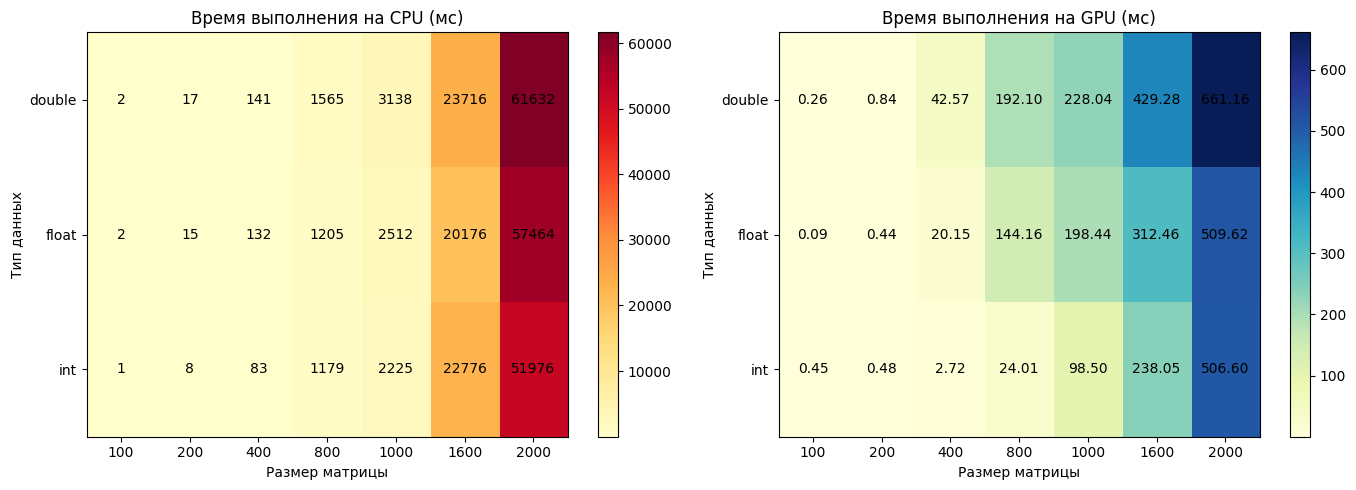

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_cpu = df.pivot(index='type', columns='size', values='cpu_time_ms')
data_cpu = pivot_cpu.values
x_labels = pivot_cpu.columns.values
y_labels = pivot_cpu.index.values

im_cpu = axes[0].imshow(data_cpu, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(x_labels)))
axes[0].set_xticklabels(x_labels)
axes[0].set_yticks(range(len(y_labels)))
axes[0].set_yticklabels(y_labels)
axes[0].set_title('Время выполнения на CPU (мс)')
axes[0].set_xlabel('Размер матрицы')
axes[0].set_ylabel('Тип данных')

for i in range(data_cpu.shape[0]):
    for j in range(data_cpu.shape[1]):
        axes[0].text(j, i, f'{data_cpu[i, j]:.0f}', ha='center', va='center')

plt.colorbar(im_cpu, ax=axes[0])

pivot_gpu = df.pivot(index='type', columns='size', values='gpu_time_ms')
data_gpu = pivot_gpu.values

im_gpu = axes[1].imshow(data_gpu, cmap='YlGnBu', aspect='auto')
axes[1].set_xticks(range(len(x_labels)))
axes[1].set_xticklabels(x_labels)
axes[1].set_yticks(range(len(y_labels)))
axes[1].set_yticklabels(y_labels)
axes[1].set_title('Время выполнения на GPU (мс)')
axes[1].set_xlabel('Размер матрицы')
axes[1].set_ylabel('Тип данных')

for i in range(data_gpu.shape[0]):
    for j in range(data_gpu.shape[1]):
        axes[1].text(j, i, f'{data_gpu[i, j]:.2f}', ha='center', va='center')

plt.colorbar(im_gpu, ax=axes[1])

plt.tight_layout()
plt.savefig('heatmap_times.png', dpi=150, bbox_inches='tight')
plt.show()